# **Homework 3**

*Artificial Intelligence II - Fall Semester 2021*

*Deep Learning for Natural Language Processing*


---


## **Experiment 1: Vanilla RNN**


Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Imports**

Import needed libraries and download packages "punkt" and "popular"

In [ ]:
import pandas as pd
import scipy
from string import digits
import re

import matplotlib.pyplot as plt

import numpy as np
import nltk

nltk.download('punkt')
nltk.download('popular')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import preprocessing
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from scipy import spatial
from sklearn.manifold import TSNE
from sklearn.preprocessing import binarize, MultiLabelBinarizer
import warnings
from scipy import interp
import unicodedata
import string

# from functools import reduce
# import operator
from itertools import cycle

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchtext.vocab import GloVe, FastText
from torchtext.legacy.data import Field, Dataset, Example, BucketIterator
from torch.nn.utils.rnn import pad_sequence


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gazetteers.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/genesis.zip.
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gutenberg.zip.
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/movie_reviews.zip.
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    | 

Read train data from csv file.

In [ ]:
df_train = pd.read_csv("/content/drive/MyDrive/University/Vaccine Sentiment Dataset/vs_train.csv", index_col=[0])
df_train.head()

,tweet,label
0,Sip N Shop Come thru right now #Marjais #Popul...,0
1,I don't know about you but My family and I wil...,1
2,@MSignorile Immunizations should be mandatory....,2
3,President Obama spoke in favor of vaccination ...,0
4,"""@myfoxla: Arizona monitoring hundreds for mea...",0


Read test data from csv file.

In [ ]:
df_test = pd.read_csv("/content/drive/MyDrive/University/Vaccine Sentiment Dataset/vs_dev.csv", index_col=[0])
df_test.head()

,tweet,label
0,@user They had a massive surge in with covid d...,1
1,Required vaccines for school: Parents and guar...,0
2,“@KCStar: Two more Johnson County children hav...,0
3,NV can do better. Which states are the best (a...,2
4,Nothing like killing ourselves w/ our own fear...,2


## **Data Preprocess**



---



###Text Data Cleaning

>For the data cleaning process, the following were included: 
* Remove all whitespaces and newlines 
* Remove all special characters and punctuation
* Replace contractions with full words (despite that they might be removed   later from the stopwords)
* Splitted attached words e.g.  “ForTheWin” =>  “For The Win”
* Lowered all capital letters  
* Removed Numbers from text corpus
* Standarizing sentences

>Both train and test data are preprocessed in the same exact way.

>(reference link: [python-efficient-text-data-cleaning](https://www.geeksforgeeks.org/python-efficient-text-data-cleaning/)

In [ ]:
def numbers(x):
  return re.sub(r'[0-9]+', '', x)

def blank_space(x):
  return re.sub('[^A-Za-z0-9]+', ' ', x)

def standarize_sentence(x):
  return ''.join(''.join(word)[:2] for word in x) 

def apostrophe_words(x):
  Apos_dict={"'s":" is","'t":" not","'m":" am","'ll":" will", "'d":" would","'ve":" have","'re":" are", 
             "’s":" is","’t":" not","’m":" am", "’d":" would","’ve":" have","’re":" are", "’ll": "will"} 
  for key,value in Apos_dict.items(): 
    if key in x:
      x =  x.replace(key,value)
      return x
  return x

def split_words(x):
  return " ".join([word for word in re.split("([A-Z][a-z]+[^A-Z]*)",x) if word])

def shallow_cleaning(df):
  remove_digits = str.maketrans('', '', digits)
  df['tweet'] = df['tweet'].apply(lambda x: blank_space(x))
  df['tweet'] = df['tweet'].apply(lambda x: apostrophe_words(x))
  df['tweet'] = df['tweet'].str.strip()
  df['tweet'] = df['tweet'].str.lower()
  df['tweet'] = df['tweet'].apply(lambda x: numbers(x))
  df['tweet'] = df['tweet'].apply(lambda x: split_words(x))
  df['tweet'] = df['tweet'].apply(lambda x: standarize_sentence(x))
  return df

df_train = shallow_cleaning(df_train)
display(df_train)

,tweet,label
0,sip n shop come thru right now marjais popular...,0
1,i don t know about you but my family and i wil...,1
2,msignorile immunizations should be mandatory p...,2
3,president obama spoke in favor of vaccination ...,0
4,myfoxla arizona monitoring hundreds for measle...,0
...,...,...
15971,salon if u believe the anti vax nutcases cause...,1
15972,how do you feel about parents who don t vaccin...,0
15973,preschoolers tested for measles in simi valle...,0
15974,finance minister budget offers room to procure...,0


In [ ]:
df_test = shallow_cleaning(df_test)
display(df_test)

,tweet,label
0,user they had a massive surge in with covid de...,1
1,required vaccines for school parents and guard...,0
2,kcstar two more johnson county children have m...,0
3,nv can do better which states are the best and...,2
4,nothing like killing ourselves w our own fear ...,2
...,...,...
2277,rt abc number of measles cases reported in cal...,0
2278,evidence points to the idea that measles affec...,0
2279,where s savedyouaclick voxdotcom why you shoul...,2
2280,some of my favorite people have autism if that...,2


Mount available CUDA device

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [ ]:
!nvidia-smi -q


==============NVSMI LOG==============

Timestamp                                 : Sun Jan 30 16:50:23 2022
Driver Version                            : 460.32.03
CUDA Version                              : 11.2

Attached GPUs                             : 1
GPU 00000000:00:04.0
    Product Name                          : Tesla T4
    Product Brand                         : Tesla
    Product Architecture                  : Turing
    Display Mode                          : Enabled
    Display Active                        : Disabled
    Persistence Mode                      : Disabled
    MIG Mode
        Current                           : N/A
        Pending                           : N/A
    Accounting Mode                       : Disabled
    Accounting Mode Buffer Size           : 4000
    Driver Model
        Current                           : N/A
        Pending                           : N/A
    Serial Number                         : 1561820009437
    GPU UUID              

### Load ***GloVe*** embeddings

GloVe is an unsupervised learning algorithm for obtaining vector representations for words. Training is performed on aggregated global word-word co-occurrence statistics from a corpus, and the resulting representations showcase interesting linear substructures of the word vector space.


---

**GloVe** embedding vector is downloaded and initialized. Since the dataset we are provided is from twitter, the chosen embedding is the Twitter dataset containing 27 billion parameters and 100 dimensions.

In [ ]:
glove_embedding = GloVe(name = 'twitter.27B', dim = 100)

.vector_cache/glove.twitter.27B.zip: 1.52GB [04:46, 5.31MB/s]                            
100%|█████████▉| 1193513/1193514 [00:44<00:00, 26751.53it/s]


In [ ]:
glove_embedding_expanded = glove_embedding.vectors.unsqueeze(0) # add the batch_size dimension
h0 = torch.zeros(1, 1, 50)           # initial hidden state

print(glove_embedding_expanded.shape)

torch.Size([1, 1193514, 100])


***max_row_len(df):*** takes the dataframe and finds the longest tweet in words which sets the upper limit for the embedding we are going to use.

In [ ]:
def max_row_len(df):
  max_len = 0
  for i, r in df.iterrows():
    max_len = max(max_len, len(r['tweet'].split()))
  return max_len

max_len = max_row_len(df_train)
print(max_len)

101


## Preprocessing & Vocabulary Creation

*   Create Fields
*   Basic preprocessing for the input dataset (train & test) - tokenization and lowercase
*   Build vocabulary 


---


>**Field:**
>
>Defines a datatype together with instructions for converting to Tensor.
>
>Field class models common text processing datatypes that can be represented by tensors. It holds a Vocab object that defines the set of possible values for elements of the field and their corresponding numerical representations. The Field object also holds other parameters relating to how a datatype should be numericalized, such as a tokenization method and the kind of Tensor that should be produced.


In [ ]:
#create fields
text_field = Field(
    sequential=True,
    tokenize='spacy', 
    fix_length=max_len,
    lower=True,
    stop_words = 'english', 
    use_vocab=True
)

text_field_test = Field(
    sequential=True,
    tokenize='spacy', 
    fix_length=max_len,
    lower=True,
    stop_words = 'english',
    use_vocab=True
)

df_train['tweet'] = df_train['tweet'].astype('string')

df_test['tweet'] = df_test['tweet'].astype('string')

#basic preprocessing
preprocessed_text = df_train['tweet'].apply(
    lambda x: text_field.preprocess(x)
).astype('string')

preprocessed_text_test = df_test['tweet'].apply(
    lambda x: text_field_test.preprocess(x)
).astype('string')

label_field = Field(sequential=False, use_vocab=False, is_target=True, dtype=torch.long)
index_field = Field(sequential=False, use_vocab=False, is_target=True, dtype=torch.long)

label_field_test = Field(sequential=False, use_vocab=False, is_target=True, dtype=torch.long)
index_field_test = Field(sequential=False, use_vocab=False, is_target=True, dtype=torch.long)

#build vocabularies
text_field.build_vocab(
    preprocessed_text, 
    vectors=glove_embedding
)

text_field_test.build_vocab(
    preprocessed_text_test, 
    vectors=glove_embedding
)

## Dataset Creation

Dataframe definition with the use of the DataFrame object.


In [ ]:
class DataFrameDataset(Dataset):
  def __init__(self, df: pd.DataFrame, fields: list):
    super(DataFrameDataset, self).__init__(
        [
            Example.fromlist(list(r), fields) 
            for i, r in df.iterrows()
        ], fields
      )

Define the train and test dataset

In [ ]:
train_dataset = DataFrameDataset(
    df=df_train.reset_index(), 
    fields=(
        ('index', index_field),
        ('tweet', text_field),
        ('label', label_field)
    )
)

test_dataset = DataFrameDataset(
    df=df_test.reset_index(), 
    fields=(
        ('index', index_field_test),
        ('tweet', text_field_test),
        ('label', label_field_test)
    )
)

Iterator construction for the mini batches used in the model.

***Batch-size=64***

In [ ]:
train_iter, val_iter = BucketIterator.splits(
    datasets=(train_dataset, train_dataset), 
    batch_sizes=(64, 64),
    sort=False,
    device = device,
    shuffle = True
)

#mock_iter is never used, it is needed for the BuckeIterator to work properly as 
#I have gathered after many hours of searching on Google...
test_iter, mock_iter = BucketIterator.splits(
    datasets=(test_dataset, test_dataset), 
    batch_sizes=(64, 64),
    sort=False,
    device = device,
    shuffle = True
)

In [ ]:
def getMax(array, size):
  max = -1
  counter = 0
  for element in array:
    if max < element:
      max = element
      label = counter
    counter+=1
  return label

def getPrediction(y_pred, out_dim=1):
  res_list = []
  for line in y_pred:
    res_list.append(getMax(line, 3))
  res_df = pd.DataFrame(data=res_list, columns=['Predicted Labels'])
  if device == 'cuda':
    return torch.tensor(res_df.values, dtype=torch.long).to('cuda')
  else:
    return torch.tensor(res_df.values, dtype=torch.long)

### Define Neural Network

**Architecture:** 



*   Pretrained Embedding layer - GloVe - with vector dimensions as defined in  above code sections
*   RNN layer: fed from the embedding layer, bidirectional with dropout 0.75
*   Linear layer with input_size self.input_size and output=output_size





In [ ]:
class TweetRNN(nn.Module):
    def __init__(self, embedding, input_size, embedding_size, hidden_size, num_classes, num_layers=2):
        super().__init__()
        self.embedding = embedding
        self.input_size = input_size
        self.embedding_size = embedding_size
        self.hidden_size = hidden_size
        self.num_classes = num_classes
        self.num_layers = num_layers

        self.emb = nn.Embedding.from_pretrained(self.embedding)
        self.rnn = nn.RNN(input_size=self.embedding_size, hidden_size=self.hidden_size, bidirectional=True, batch_first=True, num_layers=self.num_layers, dropout=0.75)
        self.linear = nn.Linear(self.input_size, self.num_classes)
    
    def forward(self, x):
        x = self.emb(x)      
        rnn_out, _ = self.rnn(x)
        
        rnn_mean = None
        for i in range(self.input_size):
          if rnn_mean is None:
            rnn_mean = torch.mean(rnn_out[:,i,:], 1, True)
          else:
            rnn_mean = torch.hstack((rnn_mean, torch.mean(rnn_out[:,i,:], 1, True)))
        
        out = self.linear(rnn_mean)
        return out

### Model Initialization



*   input_size
*   hidden_dim: hidden layer size
*   output_size
*   Learning rate: after multiple experiments 0.05 is thought to be the best choice
*   Loss function: CrossEntropyLoss is used. It is considered the best choice for multiclass classiication problems.
*   Optimizer: Adam - has good performance overall. I did also try SGD but it had dissaponting results
*   Scheduler: ReduceLROnPlateau. For this implementation i used this particular scheduler (and generally a scheduler), since the model seem to get stuck in plateus during its training.



In [ ]:
hidden_size = 32
N_EPOCHS = 250
num_layers = 2
input_size = 64
net = TweetRNN(embedding=glove_embedding.vectors, input_size=input_size, embedding_size=glove_embedding.vectors.shape[1], hidden_size=hidden_size, num_classes=3, num_layers=num_layers)

for name, param in net.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

LR = 0.005
optimizer = torch.optim.Adam(net.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode='min', patience=5, factor=0.5, cooldown=2)

if device == 'cuda':
  net.to('cuda')
  criterion.to('cuda')

rnn.weight_ih_l0 torch.Size([32, 100])
rnn.weight_hh_l0 torch.Size([32, 32])
rnn.bias_ih_l0 torch.Size([32])
rnn.bias_hh_l0 torch.Size([32])
rnn.weight_ih_l0_reverse torch.Size([32, 100])
rnn.weight_hh_l0_reverse torch.Size([32, 32])
rnn.bias_ih_l0_reverse torch.Size([32])
rnn.bias_hh_l0_reverse torch.Size([32])
rnn.weight_ih_l1 torch.Size([32, 64])
rnn.weight_hh_l1 torch.Size([32, 32])
rnn.bias_ih_l1 torch.Size([32])
rnn.bias_hh_l1 torch.Size([32])
rnn.weight_ih_l1_reverse torch.Size([32, 64])
rnn.weight_hh_l1_reverse torch.Size([32, 32])
rnn.bias_ih_l1_reverse torch.Size([32])
rnn.bias_hh_l1_reverse torch.Size([32])
linear.weight torch.Size([3, 64])
linear.bias torch.Size([3])


In [ ]:
net

TweetRNN(
  (emb): Embedding(1193514, 100)
  (rnn): RNN(100, 32, num_layers=2, batch_first=True, dropout=0.75, bidirectional=True)
  (linear): Linear(in_features=64, out_features=3, bias=True)
)

### Train Network

Epochs: 250 (after the conduction of multiple experiments)

The model is trained with the entire train dataset and then tested (as a mockup) with the same dataset.

In [ ]:
train_loss = []
val_loss = []
y_test = []
prediction = []

train_stats = {'train_loss': [], 'val_loss': []}


for epoch in range(N_EPOCHS):
  batch_losses = []
  y_test = []
  prediction = []
  running_loss = 0.0
  i=0

  # Ensure net in training mode
  net.train()
  for batch in train_iter:
    # Zero out gradients
    optimizer.zero_grad()
    
    # Get net output, calculate loss, and generate gradients
    output = net(batch.tweet.T)
    loss = criterion(output, batch.label)
    # Generate gradients via autograd
    loss.backward() 
    
    # Step
    # -----------------------------------
    # Clip params
    for param in net.parameters():
        if param.grad is None:
            continue
        grad_val = torch.clamp(param.grad, -5, 5)
    optimizer.step()
    # -----------------------------------
    
    # Track loss
    # CE loss
    batch_losses.append(loss.item())
    current_loss = loss.item()
    running_loss += (current_loss - running_loss) / (i + 1)     

  print(f"Epoch {epoch:3}: Loss = {float(running_loss)}")

  train_stats['train_loss'].append(float(running_loss))
  
  # Compute the validation score
  net.eval()
  running_loss_val = 0.0

  for batch in val_iter:
    
    y_pred = net(batch.tweet.T)
    y_pred_label = getPrediction(y_pred, 3)
    
    loss = criterion(y_pred, batch.label)
    
    current_loss = loss.item()
    running_loss += (current_loss - running_loss) / (i + 1)
    
    prediction.append(y_pred_label.flatten().tolist())
    y_test.append(batch.label.cpu().tolist())
    i += 1

  train_stats['val_loss'].append(running_loss)
  scheduler.step(train_stats['val_loss'][-1])

prediction = sum(prediction, [])
y_test = sum(y_test, [])

Epoch   0: Loss = 1.0017141103744507
Epoch   1: Loss = 1.041698932647705
Epoch   2: Loss = 1.050169587135315
Epoch   3: Loss = 0.9715291261672974
Epoch   4: Loss = 0.8182652592658997
Epoch   5: Loss = 1.0044583082199097
Epoch   6: Loss = 0.9413104057312012
Epoch   7: Loss = 1.019158124923706
Epoch   8: Loss = 1.0043960809707642
Epoch   9: Loss = 0.91802579164505
Epoch  10: Loss = 0.9137079119682312
Epoch  11: Loss = 0.952835202217102
Epoch  12: Loss = 0.9540956020355225
Epoch  13: Loss = 0.9762905836105347
Epoch  14: Loss = 0.964592695236206
Epoch  15: Loss = 1.0345265865325928
Epoch  16: Loss = 0.9849244356155396
Epoch  17: Loss = 0.9970767498016357
Epoch  18: Loss = 1.0123709440231323
Epoch  19: Loss = 0.9325996041297913
Epoch  20: Loss = 1.019474983215332
Epoch  21: Loss = 0.9345268607139587
Epoch  22: Loss = 0.8922362327575684
Epoch  23: Loss = 0.878684401512146
Epoch  24: Loss = 0.8575962781906128
Epoch  25: Loss = 0.8348008990287781
Epoch  26: Loss = 0.9004548788070679
Epoch  27:

### Train Classification Report

In [ ]:
model_report = classification_report(y_test,prediction)
print(model_report)

              precision    recall  f1-score   support

           0       0.53      0.77      0.63      7458
           1       0.52      0.03      0.05      2073
           2       0.48      0.38      0.42      6445

    accuracy                           0.51     15976
   macro avg       0.51      0.39      0.37     15976
weighted avg       0.51      0.51      0.47     15976



Train Statistics Report


*   Train Loss: Model loss monitored during training phase
*   Val_Loss: Model loss monitored during evaluation phase



In [ ]:
train_stats_df = pd.DataFrame(train_stats)
display(train_stats_df)

,train_loss,val_loss
0,1.001714,0.970761
1,1.041699,0.976901
2,1.050170,0.966810
3,0.971529,0.963142
4,0.818265,0.962816
...,...,...
245,0.902586,0.956823
246,0.964969,0.956853
247,0.963112,0.956600
248,0.969682,0.956708


Graphic represantation of train and evaluation loss for train dataset

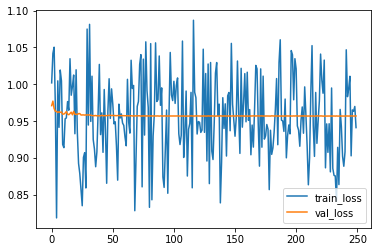

In [ ]:
train_stats_df.plot()

Batch Losses

In [ ]:
batch_losses_df = pd.DataFrame(batch_losses, columns=['Batch Loss'])
display(pd.DataFrame(batch_losses_df.T))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249
Batch Loss,0.897863,0.898296,1.073981,0.908426,1.095084,0.909675,1.082664,1.041154,1.00067,0.85989,0.981441,0.959685,0.968975,0.951784,0.902766,0.877091,0.895101,0.980895,0.876244,0.942697,0.927592,0.947255,1.08277,0.890907,0.990946,1.054739,0.933124,0.938458,1.035058,0.964216,0.938274,0.98667,0.946382,1.001521,1.059339,0.872209,0.805287,0.996111,0.922259,0.92362,...,0.869007,1.014219,1.024788,0.961627,1.074078,0.954,0.946433,0.938158,1.043896,0.936468,0.979478,0.926217,0.921841,0.994864,0.936881,0.974185,0.953055,0.940788,0.971581,0.884336,0.957539,1.013668,0.920741,0.974238,0.969322,1.004626,0.845334,1.013139,0.949828,0.877469,1.064758,0.949557,0.908509,1.044804,0.915065,0.867975,1.042679,0.991241,0.97855,0.940937


Graphic representation of batch losses

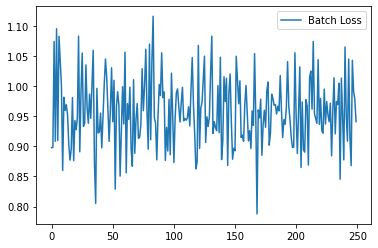

In [ ]:
batch_losses_df.plot()

Save model

In [ ]:
PATH = '/content/drive/MyDrive/University/Vaccine Sentiment Dataset/modelGlove'
torch.save({
            'epoch': 4,
            'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': float(batch_losses_df['Batch Loss'].tail(1)),
            }, PATH)

### Prediction

Model prediction for the test data.

In [ ]:
prediction = []
y_actual = []
y_test = []
batch_num = 0.0

net.eval()
accuracy = 0.0
f1 = 0.0
recall = 0.0
precision = 0.0
metrics = {'accuracy':0.0,
           'f1':0.0,
           'recall':0.0,
           'precision':0.0}

for val_batch in test_iter:
  
  batch_num += 1
  batch_prediction = []
  y_batch = []

  test_pred = net(val_batch.tweet.T)
  test_label_pred = getPrediction(test_pred, 3)

  test_pred = np.array(test_label_pred.cpu().flatten().detach().tolist())
  y_actual = np.array(val_batch.label.cpu().flatten().detach().tolist())

  batch_prediction = np.array(test_label_pred.cpu().flatten().detach().tolist())
  y_batch = np.array(val_batch.label.cpu().flatten().detach().tolist())

  prediction.append(test_label_pred.tolist())
  y_test.append(val_batch.label.cpu().flatten().detach().tolist())

  #Compute the scores.
  accuracy += accuracy_score(y_batch, batch_prediction)
  f1 += f1_score(y_batch, batch_prediction, average='micro')
  recall += recall_score(y_batch, batch_prediction, average='micro')
  precision += precision_score(y_batch, batch_prediction, average='micro')

prediction = sum(prediction, [])
y_test = sum(y_test, [])


metrics['accuracy'] = accuracy/batch_num
metrics['f1'] = f1/batch_num
metrics['recall'] = recall/batch_num
metrics['precision'] = precision/batch_num

In [ ]:
display(pd.DataFrame(pd.Series(metrics)).T)

,accuracy,f1,recall,precision
0,0.526248,0.526248,0.526248,0.526248


Classification report for the prediction made with the test data. (Model is previously trained with the vocabulary provided by the train data)

It is obvious that the prediction does not fair well...
However this outcome is somewhat expected since the train dataset is considered small to train a model of this kind and be satisfied with the prediction results. 

We can see that depending on the class and the number of examples supporting each class from the training set, they appear to have better scores. For instance class 0 has better stats than the rest since it has more examples to train on (check support in train classification results). Close behind comes class 2 and the worst performance appears in class 1, which has the smaller number of examples during its training phase.

In [ ]:
model_report = classification_report(y_test,prediction)
print(model_report)

              precision    recall  f1-score   support

           0       0.54      0.78      0.64      1065
           1       0.47      0.03      0.05       296
           2       0.50      0.40      0.44       921

    accuracy                           0.53      2282
   macro avg       0.50      0.40      0.38      2282
weighted avg       0.51      0.53      0.48      2282



### ROC-Curve

([Receiver operating characteristic](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html))

From the curve it is obvious that the False positive rate in class 0 (neutral)  is quite high.

On the other hand, the model makes good enough (can always get better), predictions for classes 1 and 2 (anti-vax and pro-vax).

All things considered, model tuning cannot always save the day. From a point after, especially in the case of neural networks, it is important to "feed" our network with a lots of data and with some variety so that it can enhance its learning. Of course that does not enclose the cases where the model overfits.

In [ ]:
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

y = label_binarize(y_actual, classes=[0, 1, 2])
n_classes = y.shape[1]

for i in range(n_classes):
  fpr[i], tpr[i], _ = roc_curve(y_actual, test_pred, pos_label=i)
  roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_actual.ravel(), test_pred.ravel(), pos_label=2)
roc_auc_micro = auc(fpr["micro"], tpr["micro"])

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:8: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  


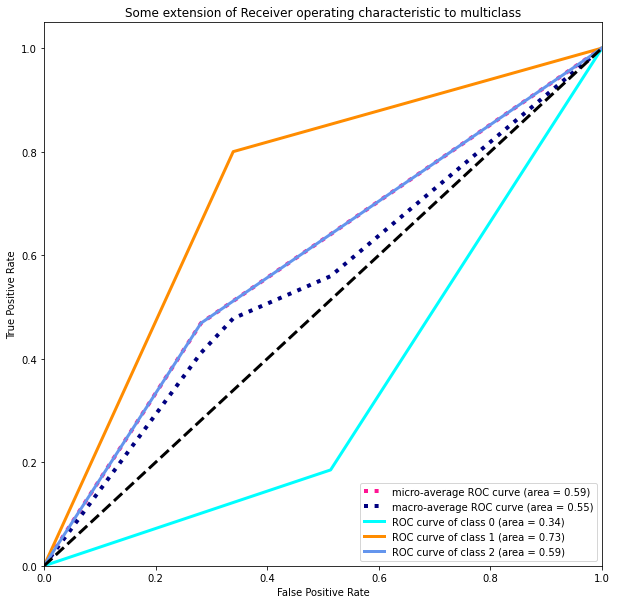

In [ ]:
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
lw = 3

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc_macro = auc(fpr["macro"], tpr["macro"])

data={"macro":roc_auc_macro, "micro":roc_auc_micro}
roc_auc_t = pd.Series(data=data, index=["macro", "micro"])

# Plot all ROC curves
plt.figure(figsize=(10,10))
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label="micro-average ROC curve (area = {0:0.2f})".format(roc_auc_t["micro"]),
    color="deeppink",
    linestyle=":",
    linewidth=4,
)

plt.plot(
    fpr["macro"],
    tpr["macro"],
    label="macro-average ROC curve (area = {0:0.2f})".format(roc_auc_t["macro"]),
    color="navy",
    linestyle=":",
    linewidth=4,
)


colors = cycle(["aqua", "darkorange", "cornflowerblue"])
for i, color in zip(range(n_classes), colors):
  plt.plot(
      fpr[i],
      tpr[i],
      color=color,
      lw=lw,
      label="ROC curve of class {0} (area = {1:0.2f})".format(i, roc_auc[(i)]),
  )

plt.plot([0, 1], [0, 1], "k--", lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Some extension of Receiver operating characteristic to multiclass")
plt.legend(loc="lower right")
plt.show()